In [1]:
from data_extractor import DataExtractor

## 1) Carga de datos desde la API de Twitter

In [2]:
import os

file_path = "data/tweets_from_api.csv"

if os.path.exists(file_path):
    extractor = DataExtractor(file_path)
    df_api = extractor.load_data()
else:
    extractor = DataExtractor()
    df_api = extractor.load_data_api(
        query="bitcoin",
        max_results=20,
        output_file=file_path
    )

df_api.head()

,tweet_id,user_name,date,text,lang,favorites,retweets,replies,views
0,2048117766066987243,AlexMasonCrypto,Sat Apr 25 19:11:42 +0000 2026,Everything is going exactly as I told you.\n\n...,en,1517,158,134,710059
1,2047753440369983734,Bitcoin_Teddy,Fri Apr 24 19:04:00 +0000 2026,A man snapped a selfie with Italy’s Prime Mini...,en,93,3,4,18037
2,2048103132178088307,SlavicNetworks,Sat Apr 25 18:13:33 +0000 2026,🚨BREAKING NEWS: POLISH CRYPTO CEO FLEES TO ISR...,en,3751,2186,235,201738
3,2048152456123568590,PeterSchiff,Sat Apr 25 21:29:33 +0000 2026,The claim that Bitcoin only has to rise by 2% ...,en,692,63,414,111614
4,2047616551923437753,SolLunix,Fri Apr 24 10:00:03 +0000 2026,In 2012 a man bet his entire life savings on B...,en,4850,221,132,1184416


## 2) Limpieza y normalización de texto

In [3]:
for i, row in df_api.iterrows():
    text_test = row.get("text", "")
    cleaned_text = extractor.clean_text(text_test)
    print(f"{i}. Original: {text_test}\nLimpio: {cleaned_text}\n")
    if i >= 9:  # Limitar a las primeras 10 filas para evitar demasiada salida
        break

0. Original: Everything is going exactly as I told you.

$79K has been hit.

The bull trap is over.

Every touch of the upper resistance gets sold.

This time is no different.

Bitcoin is entering the phase where the cycle bottom forms.

For the record, I was the only one publicly calling the exact bottom at $16,000 three years ago and the top at $126,000 in October.

If you missed those calls, don’t worry. I’ll call the next one too.

Turn notifications on.
Limpio: everything is going exactly as i told you 79k has been hit the bull trap is over every touch of the upper resistance gets sold this time is no different bitcoin is entering the phase where the cycle bottom forms for the record i was the only one publicly calling the exact bottom at 16000 three years ago and the top at 126000 in october if you missed those calls dont worry ill call the next one too turn notifications on

1. Original: A man snapped a selfie with Italy’s Prime Minister Giorgia Meloni and declared he would vote

## 3) Análisis básico - Extracción de hashtags

In [4]:
for i, row in df_api.iterrows():
    text_test = row.get("text", "")
    text_hashtags = extractor.extract_hashtags(text_test)
    print(f"{i}. Texto: {text_test}\nHashtags: {text_hashtags}\n")
    if i > 9:  # Limitar a las primeras 10 filas para evitar demasiada salida
        break

0. Texto: Everything is going exactly as I told you.

$79K has been hit.

The bull trap is over.

Every touch of the upper resistance gets sold.

This time is no different.

Bitcoin is entering the phase where the cycle bottom forms.

For the record, I was the only one publicly calling the exact bottom at $16,000 three years ago and the top at $126,000 in October.

If you missed those calls, don’t worry. I’ll call the next one too.

Turn notifications on.
Hashtags: []

1. Texto: A man snapped a selfie with Italy’s Prime Minister Giorgia Meloni and declared he would vote “no” in a referendum she backs with a “yes.” Meloni replied coolly: “It’s democracy, that’s fine.” https://t.co/icNQLLk3y1
Hashtags: []

2. Texto: 🚨BREAKING NEWS: POLISH CRYPTO CEO FLEES TO ISRAEL AS HUNDREDS OF MILLIONS IN BITCOIN VANISH FROM POLISH ACCOUNTS 🇵🇱🔥

A major Polish cryptocurrency exchange, Zondacrypto, has collapsed, leaving hundreds of ordinary Polish citizens unable to access their savings. Approximately

In [5]:
hashtag_analysis = extractor.analytics_hashtags_extended()

In [6]:
hashtag_analysis['overall'].head()

,hashtag,frequency


In [7]:
hashtag_analysis['by_user'].head()

,user_name,hashtag,frequency


In [8]:
hashtag_analysis['by_date'].head()

,date,hashtag,frequency


In [9]:
hashtag_analysis['keywords_overall'].head(20)

,keyword,frequency
0,bitcoin,31
1,at,16
2,he,15
3,his,14
4,was,12
5,by,8
6,you,8
7,has,8
8,it,8
9,as,7


### Análisis de hashtags en datos provenientes de la API

Al aplicar el análisis de hashtags sobre el dataset obtenido mediante la API de Twitter (RapidAPI), se observa que las tablas resultantes aparecen vacías. Esto se debe a una característica del propio dataset y no a un error en la implementación.

En concreto, los tweets recuperados desde la API no contienen hashtags explícitos (es decir, términos precedidos por el símbolo `#`) dentro del campo de texto ni en los metadatos proporcionados (`entities.hashtags` aparece vacío en la mayoría de los casos). Por tanto, el método de extracción de hashtags no encuentra elementos que analizar.

Esto implica que:
- El pipeline de extracción de hashtags funciona correctamente.
- La ausencia de resultados se debe a la naturaleza de los datos obtenidos desde la API.
- Este comportamiento es coherente con el contenido real de los tweets analizados.

Como alternativa, en este tipo de datasets resulta más útil trabajar con:
- **keywords** extraídas del texto,
- análisis de sentimiento,
- modelado de tópicos (LDA),
- y resumen del contenido.

En conclusión, aunque el análisis de hashtags es relevante para datasets como el de la Unidad 2, en este caso concreto su utilidad es limitada debido a la falta de hashtags en los datos proporcionados por la API.

## 4) Modelado y análisis de sentimiento

In [10]:
lda_results = extractor.model_topics(num_topics=4, passes=10)

topics = lda_results["topics"]
lda_model = lda_results["lda_model"]
corpus_bow = lda_results["corpus_bow"]
dictionary = lda_results["dictionary"]

Tópico #0: ['bottom', 'ago', 'hit', 'years', 'clearly']
Tópico #1: ['youre', 'gold', 'silver', 'ethereum', 'much']
Tópico #2: ['million', 'crypto', 'bottom', 'standard', 'gold']
Tópico #3: ['mstr', 'btc', 'old', 'rally', 'years']

Coherencia: 0.43154913460996835
Perplexity: 100.31094805409849


In [11]:
import pandas as pd

topics_df = pd.DataFrame({
    "topic": [f"Tópico {i}" for i in range(len(topics))],
    "keywords": [", ".join(topic) for topic in topics],
    "interpretation": [
        "Ciclos de mercado y mínimos del precio",
        "Comparación con activos alternativos",
        "Noticias financieras y eventos cripto",
        "Mercado institucional y comportamiento de BTC"
    ]
})

topics_df

,topic,keywords,interpretation
0,Tópico 0,"bottom, ago, hit, years, clearly",Ciclos de mercado y mínimos del precio
1,Tópico 1,"youre, gold, silver, ethereum, much",Comparación con activos alternativos
2,Tópico 2,"million, crypto, bottom, standard, gold",Noticias financieras y eventos cripto
3,Tópico 3,"mstr, btc, old, rally, years",Mercado institucional y comportamiento de BTC


In [12]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()

visualization = gensimvis.prepare(
    lda_model,
    corpus_bow,
    dictionary
)

pyLDAvis.display(visualization)

### Interpretación de tópicos

El modelo LDA ha identificado 4 tópicos principales dentro del corpus de tweets sobre Bitcoin:

- **Tópico 0 (ciclos de mercado)**: términos como *bottom, hit, years* sugieren conversaciones sobre ciclos del mercado, especialmente sobre mínimos y momentos clave del precio.

- **Tópico 1 (activos alternativos)**: aparecen palabras como *gold, silver, ethereum*, lo que indica comparaciones entre Bitcoin y otros activos financieros o criptomonedas.

- **Tópico 2 (eventos financieros / noticias)**: términos como *million, crypto, gold* reflejan noticias relacionadas con grandes cantidades de dinero, inversiones o posibles fraudes.

- **Tópico 3 (análisis técnico / mercado institucional)**: palabras como *btc, rally, mstr* (MicroStrategy) indican discusiones sobre comportamiento del mercado y actores institucionales.

### Evaluación del modelo LDA

- **Coherencia**: 0.43
- **Perplexity**: 100.31

La coherencia obtenida indica una calidad moderada en la separación de tópicos. Aunque los resultados son interpretables, aún existe cierto solapamiento entre temas.

La visualización con pyLDAvis muestra que algunos tópicos están relativamente próximos, lo que sugiere que podrían estar capturando aspectos similares del discurso.

Se podría mejorar el modelo ajustando el número de tópicos o refinando el preprocesamiento (stopwords y filtrado).

In [13]:
df_sentiment = extractor.analyze_sentiment()
df_sentiment[["text", "sentiment_polarity", "sentiment_subjectivity", "sentiment_label"]].head()

,text,sentiment_polarity,sentiment_subjectivity,sentiment_label
0,Everything is going exactly as I told you.\n\n...,0.055556,0.407407,neutral
1,A man snapped a selfie with Italy’s Prime Mini...,0.383333,0.575000,positive
2,🚨BREAKING NEWS: POLISH CRYPTO CEO FLEES TO ISR...,0.037068,0.469414,neutral
3,The claim that Bitcoin only has to rise by 2% ...,0.214286,0.514286,positive
4,In 2012 a man bet his entire life savings on B...,0.057500,0.370278,neutral


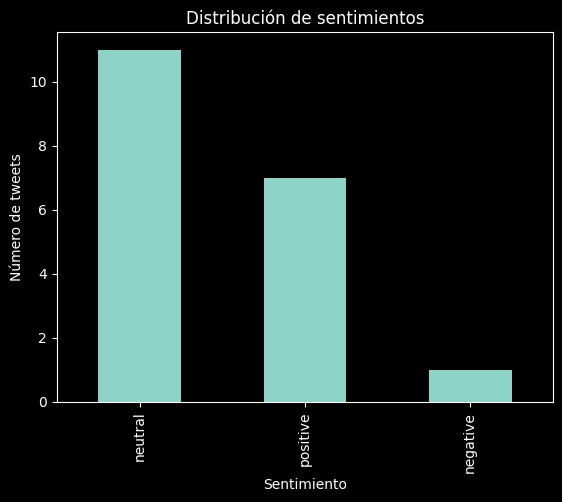

In [14]:
import matplotlib.pyplot as plt

sentiment_counts = df_sentiment["sentiment_label"].value_counts()

ax = sentiment_counts.plot(
    kind="bar",
    title="Distribución de sentimientos"
)

ax.set_xlabel("Sentimiento")
ax.set_ylabel("Número de tweets")

plt.show()

### Análisis de sentimiento

El análisis de sentimiento muestra una predominancia de tweets con polaridad **neutral o ligeramente positiva**.

Esto indica que la mayoría de los mensajes no expresan emociones extremas, sino que:
- comparten información
- realizan análisis
- comentan eventos del mercado

Los tweets positivos suelen estar asociados a expectativas de subida o éxito de inversión, mientras que los neutros reflejan información objetiva o narrativa.

In [15]:
df_parsing = extractor.parse_documents()

df_parsing[[
    "text",
    "subject",
    "verb",
    "object",
    "num_nouns",
    "num_verbs",
    "num_adjectives",
    "num_adverbs",
    "verb_frequency"
]].head()

,text,subject,verb,object,num_nouns,num_verbs,num_adjectives,num_adverbs,verb_frequency
0,Everything is going exactly as I told you.\n\n...,one,going,notifications,19,9,6,4,"{'go': 1, 'tell': 1, 'hit': 1, 'sell': 1, 'ent..."
1,A man snapped a selfie with Italy’s Prime Mini...,that,snapped,democracy,10,6,1,1,"{'snap': 1, 'declare': 1, 'vote': 1, 'back': 1..."
2,🚨BREAKING NEWS: POLISH CRYPTO CEO FLEES TO ISR...,victims,flees,justice,140,63,53,27,"{'break': 1, 'flee': 3, 'account': 1, 'collaps..."
3,The claim that Bitcoin only has to rise by 2% ...,strc,assumes,it,36,20,5,7,"{'have': 2, 'rise': 2, 'cover': 3, 'assume': 1..."
4,In 2012 a man bet his entire life savings on B...,teachers,bet,grandmother,58,33,19,6,"{'bet': 1, 'give': 2, 'put': 2, 'trade': 1, 'b..."


In [16]:
from spacy import displacy
import spacy

nlp = spacy.load("en_core_web_sm")

sample_text = extractor.data["cleaned_text"].dropna().iloc[0]
doc = nlp(sample_text)

displacy.render(doc, style="dep", jupyter=True)

In [17]:
summary = extractor.parse_and_summarize(summary_ratio=0.1)
summary

'everything is going exactly as i told you 79k has been hit the bull trap is over every touch of the upper resistance gets sold this time is no different bitcoin is entering the phase where the cycle bottom forms for the record i was the only one publicly calling the exact bottom at 16000 three years ago and the top at 126000 in october if you missed those calls dont worry ill call the next one too turn notifications on a man snapped a selfie with italys prime minister giorgia meloni and declared he would vote no in a referendum she backs with a yes meloni replied coolly its democracy thats fine breaking news polish crypto ceo flees to israel as hundreds of millions in bitcoin vanish from polish accounts a major polish cryptocurrency exchange zondacrypto has collapsed leaving hundreds of ordinary polish citizens unable to access their savings approximately 4500 bitcoin valued at hundreds of millions of dollars is either locked or missing here is the complete picture explained clearly f

### Análisis de parsing sintáctico

En esta sección se aplica **spaCy** para analizar la estructura gramatical de los tweets procesados. El objetivo es ir más allá del contenido textual y observar cómo se organizan internamente las frases.

Para cada tweet se extraen diferentes elementos lingüísticos:

- **subject**: posible sujeto principal de la oración.
- **verb**: verbo principal detectado.
- **object**: posible objeto directo o complemento asociado.
- **num_nouns**: número de sustantivos y nombres propios.
- **num_verbs**: número de verbos.
- **num_adjectives**: número de adjetivos.
- **num_adverbs**: número de adverbios.
- **verb_frequency**: frecuencia de los verbos detectados en cada texto.

Además, se genera un árbol sintáctico mediante `displacy`, que permite visualizar las relaciones de dependencia entre las palabras. En este árbol se puede observar qué palabras actúan como sujeto, verbo, objeto o modificadores dentro de la oración.

Este análisis resulta útil porque permite comprender la estructura lingüística de los tweets y detectar patrones gramaticales frecuentes dentro del corpus. También sirve como paso previo para tareas más avanzadas de NLP, como extracción de relaciones, resumen automático o análisis semántico.

### Resumen extractivo del corpus

El resumen generado recoge los principales temas del conjunto de tweets:

- discusiones sobre el comportamiento del precio de Bitcoin (ciclos, máximos y mínimos)
- noticias relevantes del sector cripto (fraudes, exchanges, pérdidas económicas)
- comparaciones con otros activos financieros (oro, plata, Ethereum)
- opiniones sobre inversión y predicciones futuras

El método extractivo selecciona las oraciones más representativas sin generar texto nuevo, lo que garantiza fidelidad al contenido original.

In [18]:
extractor.export_all_results()

Tópico #0: ['bottom', 'ago', 'hit', 'years', 'clearly']
Tópico #1: ['youre', 'gold', 'silver', 'ethereum', 'much']
Tópico #2: ['million', 'crypto', 'bottom', 'standard', 'gold']
Tópico #3: ['mstr', 'btc', 'old', 'rally', 'years']

Coherencia: 0.43154913460996835
Perplexity: 100.31094805409849


## Conclusión final

En esta segunda fase se ha ampliado el pipeline de la Unidad 2 incorporando datos obtenidos desde una API externa y técnicas avanzadas de NLP.

El análisis muestra que, aunque los tweets recuperados desde la API no contienen hashtags explícitos, sí es posible extraer información relevante mediante keywords, modelado de tópicos, análisis de sentimiento, parsing sintáctico y resumen extractivo.

Las técnicas aplicadas permiten transformar textos no estructurados en resultados interpretables, facilitando el análisis de tendencias y opiniones en redes sociales.